In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

data = pd.read_csv('ToyotaCorolla.csv')

In [2]:
data = data.dropna(subset=['Price'])
data = data.drop('Model', axis=1)

for col in data.columns:
    if data[col].isnull().any():
        if data[col].dtype in ['float64', 'int64']:
            data[col] = data[col].fillna(data[col].median())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])

X = data.drop(columns=['Price', 'Id'], errors='ignore')
y = data['Price']

data.head(5)

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
1,2,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
2,3,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
3,4,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
4,5,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


In [3]:
X.head(5)

,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,23,10,2002,46986,Diesel,90,1,Blue,0,2000,...,1,1,0,0,0,1,0,0,0,0
1,23,10,2002,72937,Diesel,90,1,Silver,0,2000,...,0,1,0,0,0,1,0,0,0,0
2,24,9,2002,41711,Diesel,90,1,Blue,0,2000,...,0,1,0,0,0,1,0,0,0,0
3,26,7,2002,48000,Diesel,90,0,Black,0,2000,...,0,1,0,0,0,1,0,0,0,0
4,30,3,2002,38500,Diesel,90,0,Black,0,2000,...,1,1,0,1,0,1,0,0,0,0


In [4]:

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 861
Размер валидационной выборки: 287
Размер тестовой выборки: 288


In [5]:
X_train_enc = X_train.copy()
X_val_enc = X_val.copy()
X_test_enc = X_test.copy()

cat_cols = X_train_enc.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    X_train_enc[cat_cols] = encoder.fit_transform(X_train_enc[cat_cols])
    X_val_enc[cat_cols] = encoder.transform(X_val_enc[cat_cols])
    X_test_enc[cat_cols] = encoder.transform(X_test_enc[cat_cols])

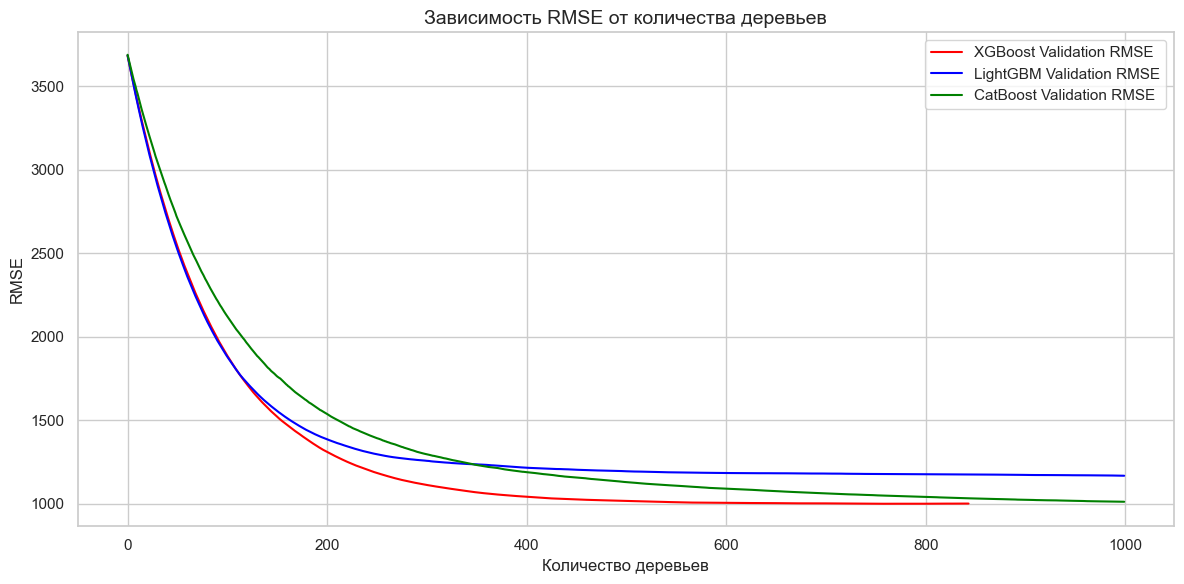

In [6]:
MAX_TREES = 1000
LEARNING_RATE = 0.01
EARLY_STOPPING_ROUNDS = 50

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, 
                             early_stopping_rounds=EARLY_STOPPING_ROUNDS)
xgb_model.fit(X_train_enc, y_train, eval_set=[(X_val_enc, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, 
                              verbose=-1, early_stopping_rounds=EARLY_STOPPING_ROUNDS)
lgb_model.fit(X_train_enc, y_train, eval_set=[(X_val_enc, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', 
                                random_seed=42, early_stopping_rounds=EARLY_STOPPING_ROUNDS)
cb_model.fit(X_train_enc, y_train, eval_set=(X_val_enc, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['validation']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
SELECTED_N_ESTIMATORS = 400

In [8]:
class MyBoost:
  def __init__(self, n=400, lr=0.05, depth=7, subsample=1.0, colsample_bytree=1.0, seed=42) -> None:
      self.n = n
      self.lr = lr
      self.depth = depth
      self.subsample = subsample
      self.colsample_bytree = colsample_bytree
      self.seed = seed

      self.trees = []
      self.initial_leaf = None
      self.n_features_ = None

  def fit(self, X, y):
    X = np.array(X)
    y = np.asarray(y)

    self.initial_leaf = y.mean()
    predictions = np.full(len(y), self.initial_leaf)

    n_samples, n_features = X.shape
    self.n_features_ = n_features
    rng = np.random.RandomState(self.seed if self.seed is not None else 42)

    for _ in range(self.n):
      antigrad = y - predictions

      if self.subsample < 1.0:
         n_rows = int(n_samples * self.subsample)
         row_idx = rng.choice(n_samples, size=n_rows, replace=False)
         X_fit = X[row_idx]
         y_fit = antigrad[row_idx]
      else:
         X_fit = X
         y_fit = antigrad

      col_idx = None
      if self.colsample_bytree < 1.0:
         n_cols = int(n_features * self.colsample_bytree)
         col_idx = rng.choice(n_features, size=n_cols, replace=False)
         X_fit = X_fit[:, col_idx]

      tree = DecisionTreeRegressor(max_depth=self.depth, 
                                   random_state=rng.randint(0, 2**31), 
                                   criterion='squared_error')

      tree.fit(X_fit, y_fit)

      self.trees.append((tree, col_idx))

      if col_idx is not None:
         predictions += tree.predict(X[:, col_idx]) * self.lr
      else:
         predictions += tree.predict(X) * self.lr

    return self

  def predict(self, X):
    X = np.array(X)
    predictions = np.full(X.shape[0], self.initial_leaf)
    for tree, col_idx in self.trees:
      if col_idx is not None:
         X_subset = X[:, col_idx]
      else:
         X_subset = X
      predictions += tree.predict(X_subset) * self.lr
    return predictions
  
  @property
  def feature_importances_(self):
    importances = np.zeros(self.n_features_)
    for tree, col_idx in self.trees:
      tree_imp = tree.feature_importances_
      if col_idx is not None:
        full_imp = np.zeros(self.n_features_)
        full_imp[col_idx] = tree_imp
      else:
        full_imp = tree_imp
      importances += full_imp * self.lr

    total = importances.sum()
    if total > 0:
      importances /= total
    return importances

In [9]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train_enc, X_val_enc])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.01, 0.03], 
    'max_depth': [3, 4, 5],          
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 0.5],      
    'reg_lambda': [1.0, 3.0]
}

grid_lgb = {
    'learning_rate': [0.01, 0.03],
    'num_leaves': [15, 31],        
    'subsample': [0.8, 1.0],
    'min_child_samples': [20, 30]  
}

grid_cat = {
    'learning_rate': [0.01, 0.03],
    'depth': [3, 4, 5],         
    'subsample': [0.8, 1.0],
    'l2_leaf_reg': [3.0, 5.0]     
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train_enc, y_train)
        preds = model.predict(X_val_enc)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 975.1857
Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 1.0}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 1145.9426
Лучшие параметры: {'learning_rate': 0.03, 'min_child_samples': 20, 'num_leaves': 15, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 988.5490
Лучшие параметры: {'depth': 4, 'l2_leaf_reg': 3.0, 'learning_rate': 0.03, 'subsample': 0.8}



Обучение модели: XGBoost...
Обучение модели: LightGBM...
Обучение модели: CatBoost...
Обучение модели: MyBoost...


,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,0.443,688.5531,877.8480,0.9422
1,LightGBM,0.735,748.3299,968.4004,0.9297
2,CatBoost,0.109,697.6850,903.0090,0.9389
3,MyBoost,0.403,718.5629,910.7392,0.9378


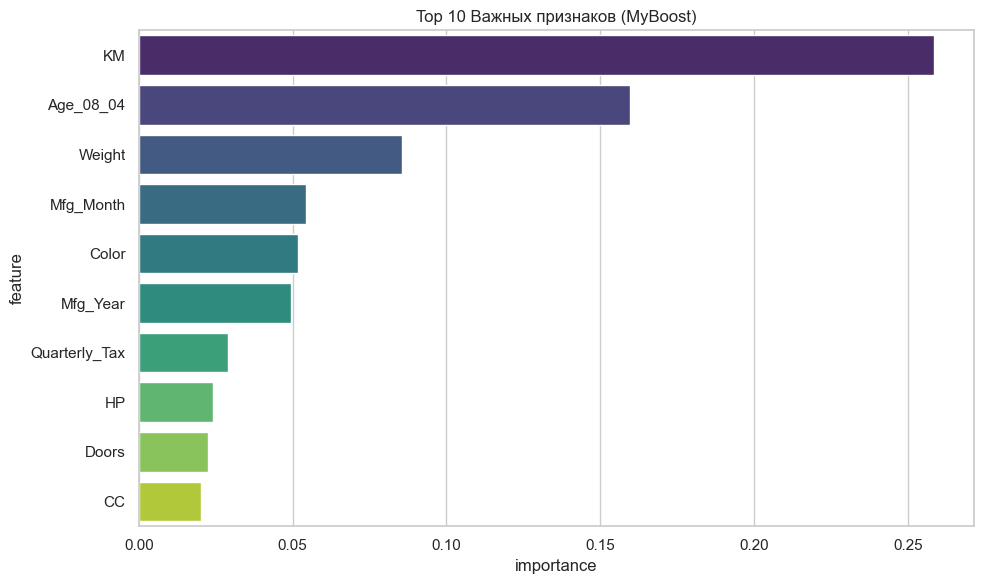

In [10]:
results = []

models_config = {
    'XGBoost': xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **best_params_dict.get('XGBoost', {})),
    'LightGBM': lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **best_params_dict.get('LightGBM', {})),
    'CatBoost': cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, verbose=0, **best_params_dict.get('CatBoost', {})),
    'MyBoost': MyBoost(n=SELECTED_N_ESTIMATORS, lr=0.05, depth=4, subsample=0.8, colsample_bytree=0.8, seed=42) # Изменил depth на 4 для стабильности
}

for name, model in models_config.items():
    print(f"Обучение модели: {name}...")
    
    start_time = time.time()
    
    model.fit(X_train_full, y_train_full)
    
    train_time = time.time() - start_time

    preds = model.predict(X_test_enc)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)


if 'MyBoost' in models_config:
    try:
        my_boost_model = models_config['MyBoost']
        importances = my_boost_model.feature_importances_
        feature_names = X_train_full.columns.tolist()
        
        feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
        feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(10)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
        plt.title('Top 10 Важных признаков (MyBoost)')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Warning: Could not plot MyBoost feature importances: {e}")

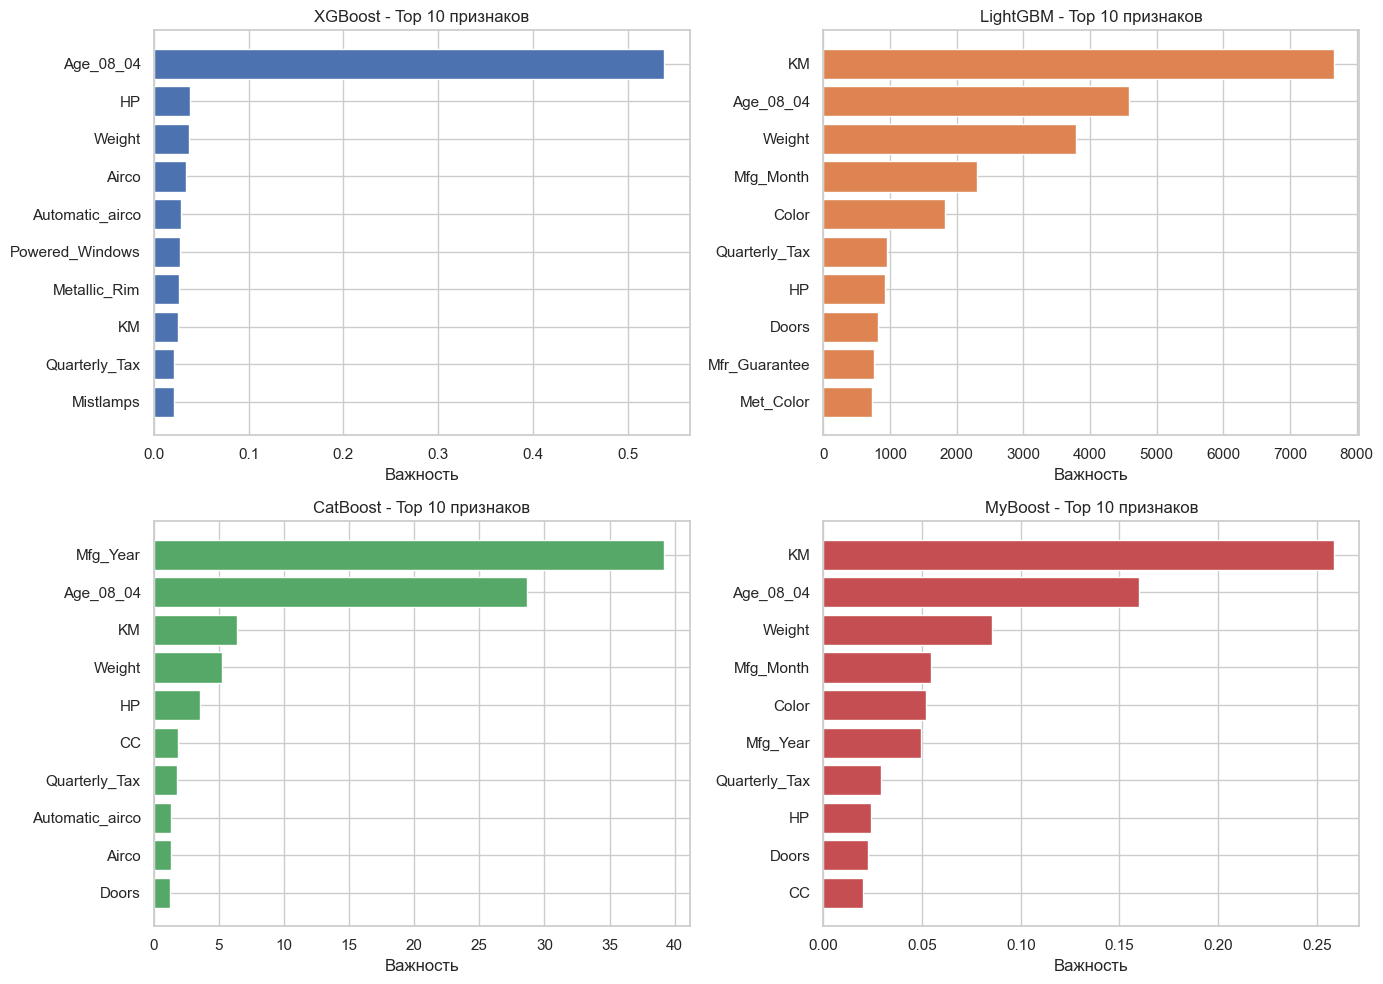

In [11]:
def plot_feature_importances_comparison(models_dict, X, top_n=10):
    
    feature_names = X.columns.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (name, model) in enumerate(models_dict.items()):
        # Получаем важность признаков
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
        else:
            continue
            
        feat_imp = pd.DataFrame({
            'feature': feature_names, 
            'importance': importances
        }).sort_values('importance', ascending=False).head(top_n)
        
        axes[idx].barh(feat_imp['feature'], feat_imp['importance'], color=f'C{idx}')
        axes[idx].set_xlabel('Важность')
        axes[idx].set_title(f'{name} - Top {top_n} признаков')
        axes[idx].invert_yaxis()  # Самый важный сверху
        
    plt.tight_layout()
    plt.show()

models_to_compare = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model, 
    'CatBoost': cb_model,
    'MyBoost': my_boost_model 
}
plot_feature_importances_comparison(models_to_compare, X_train_full)